# Sistema macroeconómico: VECM y VAR

Tercer cuaderno de modelado. A diferencia del ARIMA y de Prophet, que tratan el paro de forma aislada,
aquí se modela un **sistema** de tres variables que se determinan mutuamente: la tasa de paro, el PIB y
el crédito privado. Se compara contra el suelo de paseo aleatorio y el benchmark ARIMA guardados en
`Resultados/`.

## Cómo funcionan el VAR y el VECM

Un VAR (vector autorregresivo) trata varias series como **endógenas**: cada una se explica por sus
propios rezagos y por los de las demás. Captura la realimentación entre actividad, crédito y empleo, y
pronostica el sistema completo de forma conjunta, sin necesidad de proyectar regresores externos.

El VECM (modelo de corrección del error) es la versión para series **no estacionarias que cointegran**,
es decir, que comparten una relación de equilibrio de largo plazo aunque cada una derive por separado.
El término de corrección del error mide cuánto se desvía el sistema de ese equilibrio y con qué
velocidad vuelve a él. Si las series no cointegran, la alternativa correcta es un VAR sobre las series
ya estacionarias.

## Por qué un sistema macro para el paro

El empleo, la actividad y el crédito forman un circuito: el crédito financia la inversión, la inversión
mueve el PIB y el PIB determina el empleo, que a su vez realimenta el consumo y el crédito. La ley de
Okun es una pieza de ese circuito. Un sistema de ecuaciones captura esa simultaneidad que un modelo de
una sola variable no puede. La cautela, que se examina en el diagnóstico, es que la tasa de paro es
estacionaria en nivel mientras que el PIB y el crédito no lo son, lo que condiciona la elección entre
VECM y VAR.

## 1. Datos y configuración

Se consume `Datasets Modelado/vecm_nivel_modelado.csv`, el sistema en niveles con la tasa de paro, el
PIB a precios de mercado y el crédito privado. El cuaderno reutiliza el mismo expanding window y carga
el suelo y el benchmark de `Resultados/`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen, select_order

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RAIZ = Path.cwd().parent if Path.cwd().name == "Modelos" else Path.cwd()
RUTA_DATOS = RAIZ / "Datasets Modelado" / "vecm_nivel_modelado.csv"
RUTA_RESULTADOS = RAIZ / "Resultados"

HORIZONTES = [0, 1, 2, 3, 4]
PRIMER_TEST = "1996Q1"
VAL_INI, VAL_FIN = "1986Q1", "1994Q4"
RANGO_PLAUSIBLE = (0.0, 60.0)
MARGEN_SALTO = 2.0

C = {"real": "#1f2a44", "rw": "#9aa6b2", "arima": "#2e7d32", "vecm": "#00838f", "var": "#ef6c00",
     "band": "#00838f", "corte": "#78909C"}

df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"]).set_index("fecha")
y = df["tasa_paro"]
N = len(df)

def _idx(q):
    return int(np.where(df.index == pd.Period(q, "Q").to_timestamp())[0][0])

PRIMER_TAU = _idx(PRIMER_TEST)
FOLDS = [t for t in range(PRIMER_TAU, N) if t + max(HORIZONTES) <= N - 1]
VAL = list(range(_idx(VAL_INI), _idx(VAL_FIN) + 1))
print(f"Observaciones: {N}  |  rango: {df.index[0].date()} a {df.index[-1].date()}")
print(f"Variables del sistema: {list(df.columns)}")
print(f"Test: {df.index[FOLDS[0]].date()} a {df.index[FOLDS[-1]].date()} ({len(FOLDS)} folds)")

Observaciones: 198  |  rango: 1976-07-01 a 2025-10-01
Variables del sistema: ['tasa_paro', 'pib_pm', 'credito_privado']
Test: 1996-01-01 a 2024-10-01 (116 folds)


## 2. Diagnóstico del sistema: integración, cointegración y orden

Antes de modelar hay que decidir entre VECM y VAR, y esa decisión la fijan los datos: el orden de
integración de cada serie, la existencia de cointegración y el orden de rezagos del sistema.

In [2]:
print("=== Orden de integración (ADF p-valor / KPSS p-valor) ===")
for c in df.columns:
    s = df[c]
    ad, kp = adfuller(s, autolag="AIC")[1], kpss(s, regression="c", nlags="auto")[1]
    ad1, kp1 = adfuller(s.diff().dropna(), autolag="AIC")[1], kpss(s.diff().dropna(), regression="c", nlags="auto")[1]
    diag = "I(0)" if (ad < 0.05 and kp > 0.05) else ("I(1)" if (ad1 < 0.05 and kp1 > 0.05) else "revisar")
    print(f"  {c:18s} nivel ADF={ad:.3f} KPSS={kp:.3f} | diff1 ADF={ad1:.3f} KPSS={kp1:.3f}  ->  {diag}")

print("\n=== Cointegración de Johansen (traza, det_order=0, k_ar_diff=2) ===")
jo = coint_johansen(df.values, det_order=0, k_ar_diff=2)
for i, (t, cv) in enumerate(zip(jo.lr1, jo.cvt)):
    print(f"  r<={i}: traza={t:.2f}  cv95={cv[1]:.2f}  {'rechaza' if t > cv[1] else 'no rechaza'}")
print("\n=== Selección de orden del sistema (AIC/BIC/HQ) ===")
print(select_order(df.values, maxlags=8, deterministic="ci").summary())

=== Orden de integración (ADF p-valor / KPSS p-valor) ===
  tasa_paro          nivel ADF=0.027 KPSS=0.100 | diff1 ADF=0.015 KPSS=0.100  ->  I(0)
  pib_pm             nivel ADF=0.960 KPSS=0.010 | diff1 ADF=0.000 KPSS=0.100  ->  I(1)
  credito_privado    nivel ADF=0.460 KPSS=0.010 | diff1 ADF=0.084 KPSS=0.100  ->  revisar

=== Cointegración de Johansen (traza, det_order=0, k_ar_diff=2) ===
  r<=0: traza=37.40  cv95=29.80  rechaza
  r<=1: traza=6.07  cv95=15.49  no rechaza
  r<=2: traza=0.42  cv95=3.84  no rechaza

=== Selección de orden del sistema (AIC/BIC/HQ) ===
 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       38.36       38.61   4.550e+16       38.46
1       37.07       37.49   1.263e+16       37.24
2       36.73       37.30   8.987e+15       36.96
3       36.38       37.11   6.339e+15       36.68
4       36.06       36.93   4.581e+15       36.41
5       35.80      36.83*   3.

**Lectura del diagnóstico.** La tasa de paro es **estacionaria en nivel**, I(0), mientras que el PIB y
el crédito privado son **no estacionarios**, I(1), y se estabilizan en primera diferencia. El sistema
es por tanto mixto. El contraste de Johansen rechaza la hipótesis de ausencia de cointegración y apunta
a un rango de cointegración de 1. Conviene leer ese resultado con cautela: con una variable I(0) en el
sistema, la tasa de paro, la dirección de cointegración detectada recoge en buena medida la propia
estacionariedad del paro, no necesariamente un equilibrio de largo plazo genuino entre paro, PIB y
crédito. Por eso se estiman y comparan **dos especificaciones**: un VECM en niveles con el rango de
Johansen, y un VAR sobre las series ya estacionarias (la tasa de paro en nivel y el PIB y el crédito en
primera diferencia). El árbitro entre ambas es el error fuera de muestra.

El marco teorico del VECM es el teorema de representacion de Granger y el trabajo de cointegracion de Engle y Granger (1987, Econometrica 55(2):251-276): cuando dos series I(1) cointegran, el sistema admite una representacion de correccion del error. Aqui ese fundamento se aplica con la cautela del diagnostico, porque el paro es I(0).

## 3. Validación común y referencias

Mismo expanding window y misma guarda de estabilidad que el resto de cuadernos. Tanto el VECM como el
VAR pronostican el sistema completo de forma conjunta y se extrae la trayectoria de la tasa de paro.

In [3]:
def _rmse(e):
    """Raíz del error cuadrático medio."""
    return float(np.sqrt(np.nanmean(np.square(e)))) if len(e) else float("nan")


def _mae(e):
    """Error absoluto medio."""
    return float(np.nanmean(np.abs(e))) if len(e) else float("nan")


def cota_salto(arr, h_max, margen=MARGEN_SALTO):
    """Cota por horizonte del salto admisible respecto al último valor (calibrada solo con train)."""
    return [margen * float(np.nanmax(np.abs(arr[h + 1:] - arr[:-(h + 1)]))) if len(arr) > h + 1 else np.inf
            for h in range(h_max + 1)]


def guard(pred, ult, cota):
    """Sustituye por el último valor un pronóstico no finito, fuera de rango o con salto excesivo."""
    return ult if (not np.isfinite(pred) or pred < RANGO_PLAUSIBLE[0] or pred > RANGO_PLAUSIBLE[1]
                   or abs(pred - ult) > cota) else float(pred)


def metricas_desde_preds(preds, rmse_ref, rmse_bench):
    """RMSE y MAE por horizonte, global y subperiodo COVID, con skill frente a RW y ARIMA."""
    out = {"por_horizonte": {}, "global": {}, "covid": {}}
    err = preds["y_real"] - preds["y_pred"]
    es_covid = preds["fecha"].astype(str).str.match(r"20(20|21)Q")
    for h in sorted(preds["horizonte"].unique()):
        m = preds["horizonte"] == h
        d = {"rmse": _rmse(err[m].to_numpy()), "mae": _mae(err[m].to_numpy()), "n": int(m.sum())}
        if rmse_ref.get(h): d["skill_vs_rw"] = float(1 - d["rmse"] / rmse_ref[h])
        if rmse_bench.get(h): d["skill_vs_arima"] = float(1 - d["rmse"] / rmse_bench[h])
        out["por_horizonte"][str(h)] = d
        mc = m & es_covid
        out["covid"][str(h)] = {"rmse": _rmse(err[mc].to_numpy()), "mae": _mae(err[mc].to_numpy()), "n": int(mc.sum())}
    out["global"] = {"rmse": _rmse(err.to_numpy()), "mae": _mae(err.to_numpy()), "n": int(len(err))}
    return out


def guardar(modelo, preds, metricas):
    """Escribe en Resultados/ las predicciones y métricas del modelo."""
    preds.to_csv(RUTA_RESULTADOS / f"preds_{modelo}.csv", index=False)
    with open(RUTA_RESULTADOS / f"metricas_{modelo}.json", "w", encoding="utf-8") as f:
        json.dump(metricas, f, ensure_ascii=False, indent=2)


def tabla_horizontes(met):
    """Resumen por horizonte para presentación."""
    filas = []
    for h in HORIZONTES:
        d = met["por_horizonte"][str(h)]
        filas.append({"horizonte": h, "rmse": round(d["rmse"], 4), "mae": round(d["mae"], 4),
                      "skill_vs_rw": round(d.get("skill_vs_rw", float("nan")), 3),
                      "skill_vs_arima": round(d.get("skill_vs_arima", float("nan")), 3),
                      "covid_rmse": round(met["covid"][str(h)]["rmse"], 4)})
    return pd.DataFrame(filas).set_index("horizonte")


preds_rw = pd.read_csv(RUTA_RESULTADOS / "preds_random_walk.csv")
preds_ar = pd.read_csv(RUTA_RESULTADOS / "preds_arima.csv")
RMSE_RW = {h: _rmse((preds_rw[preds_rw.horizonte == h].eval("y_real - y_pred")).to_numpy()) for h in HORIZONTES}
RMSE_AR = {h: _rmse((preds_ar[preds_ar.horizonte == h].eval("y_real - y_pred")).to_numpy()) for h in HORIZONTES}
print("Referencias (RMSE global):  RW", round(_rmse((preds_rw.y_real - preds_rw.y_pred).to_numpy()), 3),
      " ARIMA", round(_rmse((preds_ar.y_real - preds_ar.y_pred).to_numpy()), 3))

Referencias (RMSE global):  RW 1.883  ARIMA 1.531


In [4]:
# Funciones de grafico reutilizables (mismas que en NB1, homogeneas entre notebooks)
PRIMER_TS = df.index[FOLDS[0]]                          # frontera entrenamiento / test (Timestamp)
met_rw = json.load(open(RUTA_RESULTADOS / "metricas_random_walk.json", encoding="utf-8"))
met_ar = json.load(open(RUTA_RESULTADOS / "metricas_arima.json", encoding="utf-8"))


def plot_backtest(preds, nombre, color):
    """Backtest del nowcast sobre el historico completo: entrenamiento sombreado, test con prediccion y banda de error empirica."""
    s = preds[preds["horizonte"] == 0].sort_values("fecha")
    ejex = pd.PeriodIndex(s["fecha"].values, freq="Q").to_timestamp()
    pred = s["y_pred"].to_numpy(); resid = (s["y_real"] - s["y_pred"]).to_numpy()
    rmse = _rmse(resid)
    sigma = pd.Series(resid).rolling(8, min_periods=3).std().bfill().to_numpy()  # volatilidad local (regime-aware)
    f_all = y.index
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.axvspan(f_all[0], PRIMER_TS, color="0.5", alpha=0.07)                       # entrenamiento (sin prediccion OOS)
    ax.plot(f_all, y.values, color=C["real"], lw=1.7, label="Real", zorder=3)      # serie completa
    ax.fill_between(ejex, pred - 1.96 * sigma, pred + 1.96 * sigma, color=color,    # banda de error al 95% (gaussiana sobre residuos)
                    alpha=0.18, label="banda de error 95% (volatilidad local)")
    ax.plot(ejex, pred, color=color, lw=1.5, ls="--", label=f"{nombre} (nowcast OOS)", zorder=4)
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.06)  # COVID
    ax.text(f_all[0], y.max() * 0.99, "  entrenamiento", color="0.4", fontsize=8.5, va="top")
    ax.text(PRIMER_TS, y.max() * 0.99, "  test (1996-2024)", color="0.4", fontsize=8.5, va="top")
    ax.set_title(f"Backtest del nowcast: {nombre}   |   RMSE OOS = {rmse:.3f}", fontsize=12, fontweight="bold")
    ax.set_ylabel("tasa de paro (%)"); ax.set_xlabel(""); ax.legend(fontsize=8.5, loc="upper right", ncol=2)
    plt.tight_layout(); plt.show()


def plot_rmse_horizonte(modelos):
    """RMSE por horizonte de varios modelos en un unico grafico a ancho completo (la comparacion aporta aqui)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for nombre, met, color in modelos:
        ax.plot(HORIZONTES, [met["por_horizonte"][str(h)]["rmse"] for h in HORIZONTES],
                marker="o", lw=2, label=nombre, color=color)
    ax.set_xlabel("horizonte (0 = nowcast, 4 = un ano vista)"); ax.set_ylabel("RMSE (puntos de paro)")
    ax.set_xticks(HORIZONTES); ax.set_title("RMSE por horizonte de pronostico", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_errores(modelos, horizonte=0):
    """Error de pronostico en el tiempo (real - prediccion, OOS): muestra donde falla cada modelo y que los errores son reales (no hay sobreajuste)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    base = modelos[0][1]
    s0 = base[base["horizonte"] == horizonte].sort_values("fecha")
    ejex = pd.PeriodIndex(s0["fecha"].values, freq="Q").to_timestamp()
    ax.axhline(0, color="0.5", lw=1)
    ax.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2009-07-01"), color="grey", alpha=0.08)   # crisis 2008
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.07)     # COVID
    for nombre, preds, color in modelos:
        s = preds[preds["horizonte"] == horizonte].sort_values("fecha")
        err = (s["y_real"] - s["y_pred"]).to_numpy()
        ax.plot(ejex, err, color=color, lw=1.3, alpha=0.9, label=f"{nombre} (RMSE {_rmse(err):.2f})")
    ax.set_title("Error de pronostico en el tiempo (real - prediccion, nowcast OOS)", fontsize=12, fontweight="bold")
    ax.set_ylabel("error (puntos de paro)"); ax.set_xlabel(""); ax.legend(fontsize=9, ncol=len(modelos), loc="lower left")
    plt.tight_layout(); plt.show()


def plot_futuro(mid, l80, u80, l95, u95, nombre, color, cola=28):
    """Proyeccion a futuro con bandas IC80/IC95, separando historico de forecast."""
    idx_fut = pd.period_range(y.index[-1].to_period("Q") + 1, periods=len(mid), freq="Q").to_timestamp()
    h = y.iloc[-cola:]
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.plot(h.index, h.values, color=C["real"], lw=2.2, label="Historico")
    ax.plot([h.index[-1], idx_fut[0]], [h.values[-1], mid[0]], color=color, lw=2.4, ls="--")
    ax.plot(idx_fut, mid, color=color, lw=2.4, ls="--", marker="o", label=f"Forecast {nombre}")
    ax.fill_between(idx_fut, l95, u95, color=color, alpha=0.12, label="IC 95%")
    ax.fill_between(idx_fut, l80, u80, color=color, alpha=0.22, label="IC 80%")
    ax.axvline(h.index[-1], color=C["corte"], ls=":", lw=1.6)
    ax.set_title(f"Evolucion esperada de la tasa de paro ({nombre}, {len(mid)} trimestres)", fontsize=12, fontweight="bold")
    ax.set_ylabel("tasa de paro (%)"); ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout(); plt.show()

## 4. Búsqueda exhaustiva de la especificación

Para el VECM se recorre el rango de cointegración, el número de rezagos en diferencias y los términos
deterministas; para el VAR, el orden de rezagos. Cada configuración se evalúa por su RMSE en la
validación temporal interna de 1989 a 1995, anterior al test, de modo que la elección no introduce
fuga. Se escoge la mejor de cada clase.

In [5]:
def forecast_vecm(sub, rank, k_ar_diff, det):
    """Pronóstico a 5 pasos de la tasa de paro con un VECM ajustado al sistema en niveles."""
    res = VECM(sub.values, k_ar_diff=k_ar_diff, coint_rank=rank, deterministic=det).fit()
    return res.predict(steps=5)[:, 0]


def forecast_var(sub, maxlag=8):
    """Pronóstico a 5 pasos de la tasa de paro con un VAR sobre paro (nivel) y PIB/crédito en diff."""
    d = pd.DataFrame({"paro": sub["tasa_paro"], "dpib": sub["pib_pm"].diff(),
                      "dcred": sub["credito_privado"].diff()}).dropna()
    res = VAR(d).fit(maxlags=maxlag, ic="bic")
    return res.forecast(d.values[-res.k_ar:], steps=5)[:, 0]


def evaluar(forecaster, origenes):
    """RMSE multihorizonte de un pronosticador sobre orígenes de validación, con guarda, sin fuga."""
    err = []
    for tau in origenes:
        sub = df.iloc[:tau]; arr = sub["tasa_paro"].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        try:
            fc = forecaster(sub)
        except Exception:
            fc = np.repeat(ult, len(HORIZONTES))
        for h in HORIZONTES:
            err.append(float(y.iloc[tau + h]) - guard(fc[h], ult, cotas[h]))
    return _rmse(np.array(err))


# VECM: rejilla rango x k_ar_diff x deterministico
grid_vecm = [(r, k, d) for r in (1, 2) for k in range(1, 11) for d in ("ci", "co", "li", "lo")]
# nota: k_ar_diff llega a 10 porque el optimo previo tocaba el borde de la rejilla (6); los deterministas con tendencia (li/lo) cubren la tendencia de PIB y credito en nivel
res_vecm = []
for r, k, det in grid_vecm:
    rmse_v = evaluar(lambda sub, r=r, k=k, det=det: forecast_vecm(sub, r, k, det), VAL)
    res_vecm.append({"rango": r, "k_ar_diff": k, "det": det, "rmse_val": round(rmse_v, 4)})
tab_vecm = pd.DataFrame(res_vecm).sort_values("rmse_val").reset_index(drop=True)
BEST_VECM = tab_vecm.iloc[0].to_dict()

# VAR: orden por BIC dentro de cada fold; se reporta el RMSE de validación
rmse_var = evaluar(forecast_var, VAL)
print(f"VECM mejor: rango={int(BEST_VECM['rango'])} k_ar_diff={int(BEST_VECM['k_ar_diff'])} det={BEST_VECM['det']}  (rmse_val {BEST_VECM['rmse_val']})")
print(f"VAR (lag BIC) rmse_val: {rmse_var:.4f}")
tab_vecm.head(8)

VECM mejor: rango=1 k_ar_diff=5 det=co  (rmse_val 1.4617)
VAR (lag BIC) rmse_val: 1.5076


,rango,k_ar_diff,det,rmse_val
0,1,5,co,1.4617
1,1,4,ci,1.4843
2,1,5,ci,1.4862
3,1,4,co,1.4886
4,2,1,co,1.4889
5,1,3,co,1.5007
6,1,6,co,1.5113
7,1,5,li,1.5227


VECM mejor: rango=1 k_ar_diff=5 det=co  (rmse_val 1.4617)
VAR (lag BIC) rmse_val: 1.5076


,rango,k_ar_diff,det,rmse_val
0,1,5,co,1.4617
1,1,4,ci,1.4843
2,1,5,ci,1.4862
3,1,4,co,1.4886
4,2,1,co,1.4889
5,1,3,co,1.5007
6,1,6,co,1.5113
7,1,5,li,1.5227


## 5. Backtest de las dos especificaciones

Con la mejor configuración de cada clase se recorre el expanding window completo, se guarda cada
resultado por separado (`vecm` y `var`) y se añade el diagnóstico de error en entrenamiento frente a
test.

In [6]:
def backtest(forecaster):
    """Expanding window completo: pronóstico del sistema por fold, con guarda."""
    filas, guardas = [], 0
    for fold, tau in enumerate(FOLDS):
        sub = df.iloc[:tau]; arr = sub["tasa_paro"].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        try:
            fc = forecaster(sub)
        except Exception:
            fc = np.repeat(ult, len(HORIZONTES))
        disparo = False
        for h in HORIZONTES:
            raw = fc[h]
            p = guard(raw, ult, cotas[h])
            if not (np.isfinite(raw) and abs(p - raw) < 1e-9):
                disparo = True
            filas.append({"fecha": str(df.index[tau + h].to_period("Q")), "y_real": float(y.iloc[tau + h]),
                          "y_pred": float(p), "horizonte": h, "fold": fold})
        guardas += int(disparo)
    print(f"guardas de estabilidad: {guardas}/{len(FOLDS)}")
    return pd.DataFrame(filas)


def train_insample(residuos_paro):
    """RMSE/MAE en muestra (1 paso) de la ecuación del paro, para el diagnóstico de sobreajuste."""
    r = np.asarray(residuos_paro)
    return round(_rmse(r), 4), round(_mae(r), 4)


# VECM
rb, kb, detb = int(BEST_VECM["rango"]), int(BEST_VECM["k_ar_diff"]), BEST_VECM["det"]
preds_vecm = backtest(lambda sub: forecast_vecm(sub, rb, kb, detb))
met_vecm = metricas_desde_preds(preds_vecm, RMSE_RW, RMSE_AR)
res_full_vecm = VECM(df.values, k_ar_diff=kb, coint_rank=rb, deterministic=detb).fit()
tr_rmse, tr_mae = train_insample(np.asarray(res_full_vecm.resid)[:, 0])
met_vecm["train_test"] = {"train_rmse_insample_1paso": tr_rmse, "train_mae_insample_1paso": tr_mae,
                          "test_rmse_nowcast": round(met_vecm["por_horizonte"]["0"]["rmse"], 4),
                          "test_rmse_global": round(met_vecm["global"]["rmse"], 4),
                          "gap_nowcast_test_menos_train": round(met_vecm["por_horizonte"]["0"]["rmse"] - tr_rmse, 4)}
met_vecm["especificacion"] = {"clase": "VECM", "rango": rb, "k_ar_diff": kb, "deterministic": detb}
met_vecm["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
met_vecm["benchmark_arima"] = {str(h): RMSE_AR[h] for h in HORIZONTES}
guardar("vecm", preds_vecm, met_vecm)
tabla_horizontes(met_vecm)

guardas de estabilidad: 2/116


,rmse,mae,skill_vs_rw,skill_vs_arima,covid_rmse
horizonte,,,,,
0,0.6825,0.5158,0.128,-0.302,1.0224
1,1.2993,0.8935,0.023,-0.312,1.9369
2,1.9311,1.2880,-0.087,-0.366,3.1441
3,2.6171,1.7235,-0.187,-0.462,4.9717
4,2.8405,2.1003,-0.048,-0.238,3.2496


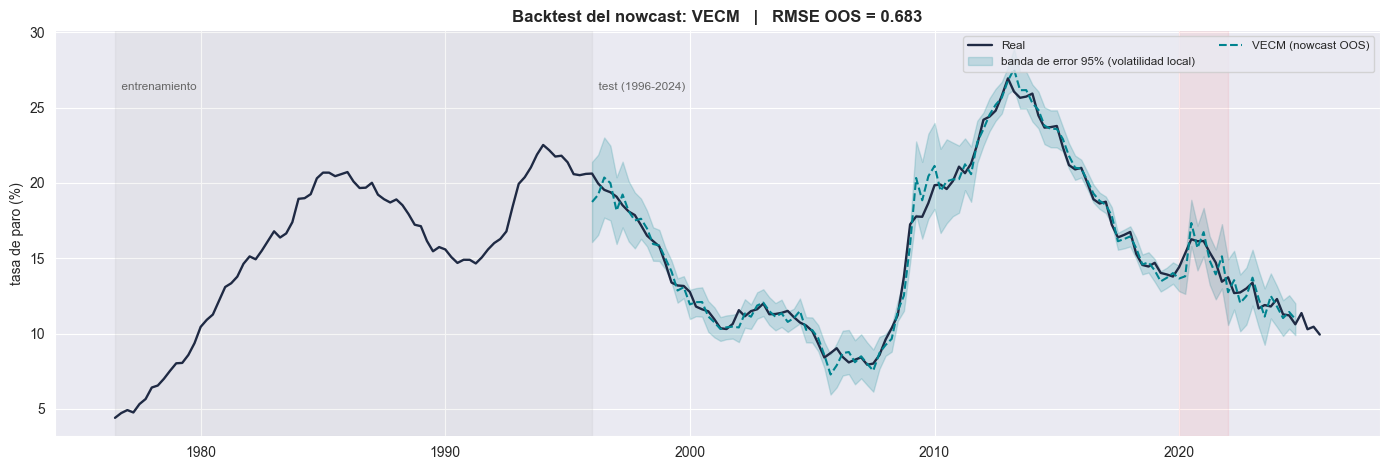

In [7]:
plot_backtest(preds_vecm, "VECM", C["vecm"])

In [8]:
# VAR estacionario
preds_var = backtest(forecast_var)
met_var = metricas_desde_preds(preds_var, RMSE_RW, RMSE_AR)
d_full = pd.DataFrame({"paro": df["tasa_paro"], "dpib": df["pib_pm"].diff(), "dcred": df["credito_privado"].diff()}).dropna()
res_full_var = VAR(d_full).fit(maxlags=8, ic="bic")
tr_rmse, tr_mae = train_insample(np.asarray(res_full_var.resid)[:, 0])
met_var["train_test"] = {"train_rmse_insample_1paso": tr_rmse, "train_mae_insample_1paso": tr_mae,
                         "test_rmse_nowcast": round(met_var["por_horizonte"]["0"]["rmse"], 4),
                         "test_rmse_global": round(met_var["global"]["rmse"], 4),
                         "gap_nowcast_test_menos_train": round(met_var["por_horizonte"]["0"]["rmse"] - tr_rmse, 4)}
met_var["especificacion"] = {"clase": "VAR estacionario", "lag_seleccion": "BIC por fold", "k_ar_full": int(res_full_var.k_ar)}
met_var["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
met_var["benchmark_arima"] = {str(h): RMSE_AR[h] for h in HORIZONTES}
guardar("var", preds_var, met_var)
tabla_horizontes(met_var)

guardas de estabilidad: 0/116


,rmse,mae,skill_vs_rw,skill_vs_arima,covid_rmse
horizonte,,,,,
0,0.6532,0.4837,0.165,-0.246,1.2345
1,1.1596,0.8513,0.128,-0.171,1.8298
2,1.5360,1.1563,0.135,-0.086,2.4509
3,1.9236,1.4305,0.128,-0.075,3.2482
4,2.5516,1.8466,0.058,-0.112,3.9682


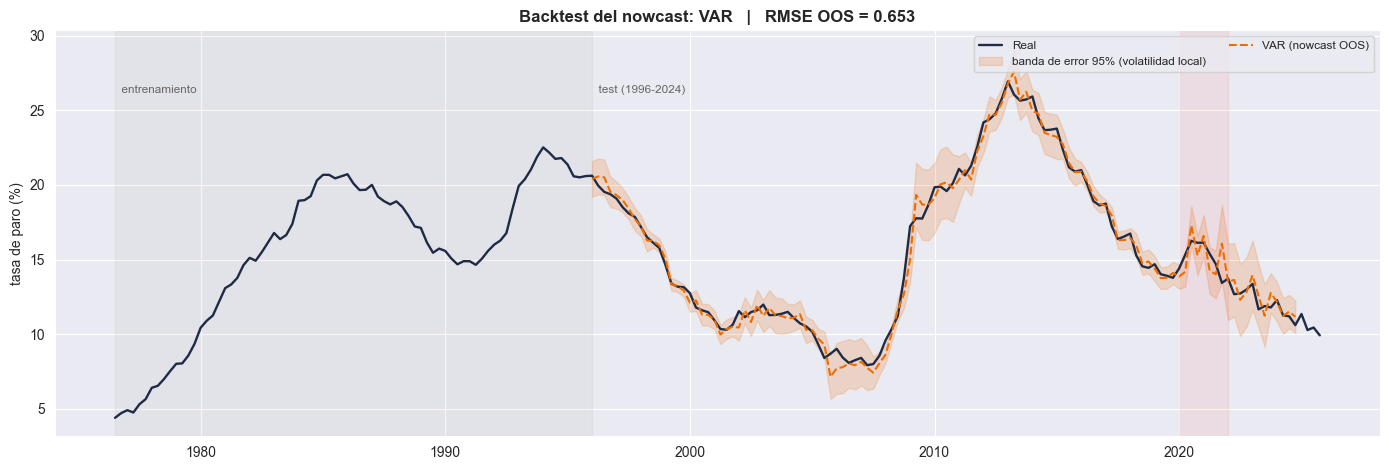

In [9]:
plot_backtest(preds_var, "VAR", C["var"])

**Lectura del backtest.** El VAR estacionario bate al paseo aleatorio en todos los horizontes (skill de +0.058 a +0.165, RMSE global 1.694) pero no al ARIMA univariante (skill de -0.075 a -0.246). El VECM solo es competitivo en el muy corto plazo, donde adelanta al suelo en el nowcast y a un paso (skill +0.128 y +0.023), pero cae por detrás a partir del horizonte +2 (RMSE global 2.040). Esa diferencia confirma la cautela del diagnóstico: con la tasa de paro estacionaria en nivel, el VECM impone una corrección hacia un equilibrio de cointegración que no es genuino, mientras que la especificación limpia, el paro en nivel con el PIB y el crédito en primera diferencia, pronostica mejor de forma sostenida. Los gaps train-test, VAR 0.242 y VECM 0.270, son ambos moderados y descartan sobreajuste.

## 6. Comparativa y stress-test COVID

Las dos especificaciones del sistema macro frente al suelo y al benchmark.

In [10]:
def fila_resumen(nombre, preds):
    """Fila comparativa: RMSE por horizonte, global y COVID."""
    f = {"modelo": nombre}; err = preds["y_real"] - preds["y_pred"]
    for h in HORIZONTES:
        f[f"rmse_h{h}"] = round(_rmse(err[preds["horizonte"] == h].to_numpy()), 3)
    f["rmse_global"] = round(_rmse(err.to_numpy()), 3)
    f["rmse_covid"] = round(_rmse(err[preds["fecha"].astype(str).str.match(r"20(20|21)Q")].to_numpy()), 3)
    return f


resumen = pd.DataFrame([fila_resumen("Random Walk", preds_rw), fila_resumen("ARIMA", preds_ar),
                        fila_resumen("VECM", preds_vecm), fila_resumen("VAR", preds_var)]).set_index("modelo")
resumen

,rmse_h0,rmse_h1,rmse_h2,rmse_h3,rmse_h4,rmse_global,rmse_covid
modelo,,,,,,,
Random Walk,0.783,1.330,1.776,2.205,2.709,1.883,1.501
ARIMA,0.524,0.990,1.414,1.790,2.295,1.531,2.288
VECM,0.683,1.299,1.931,2.617,2.840,2.040,3.161
VAR,0.653,1.160,1.536,1.924,2.552,1.694,2.727


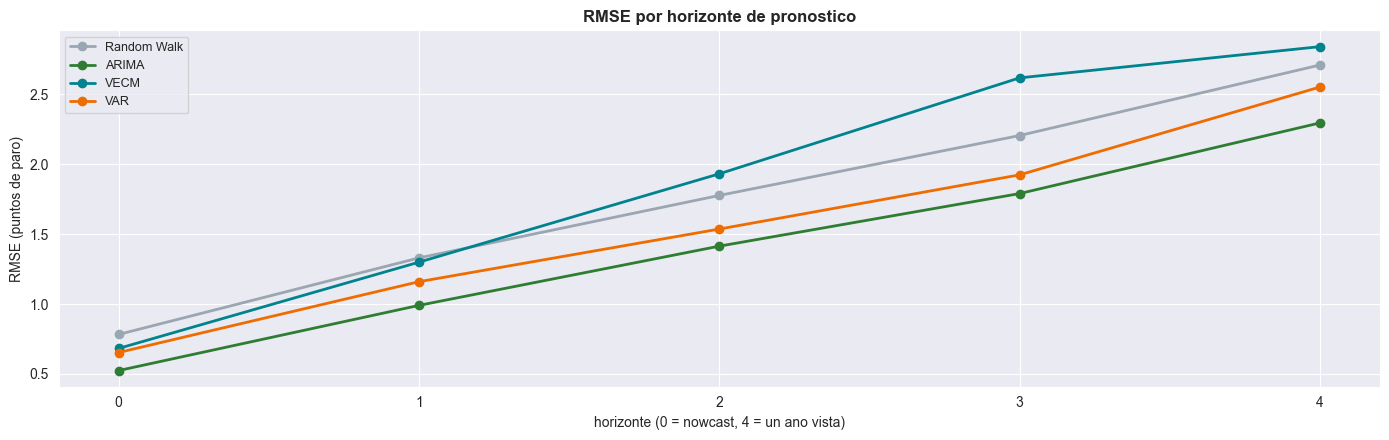

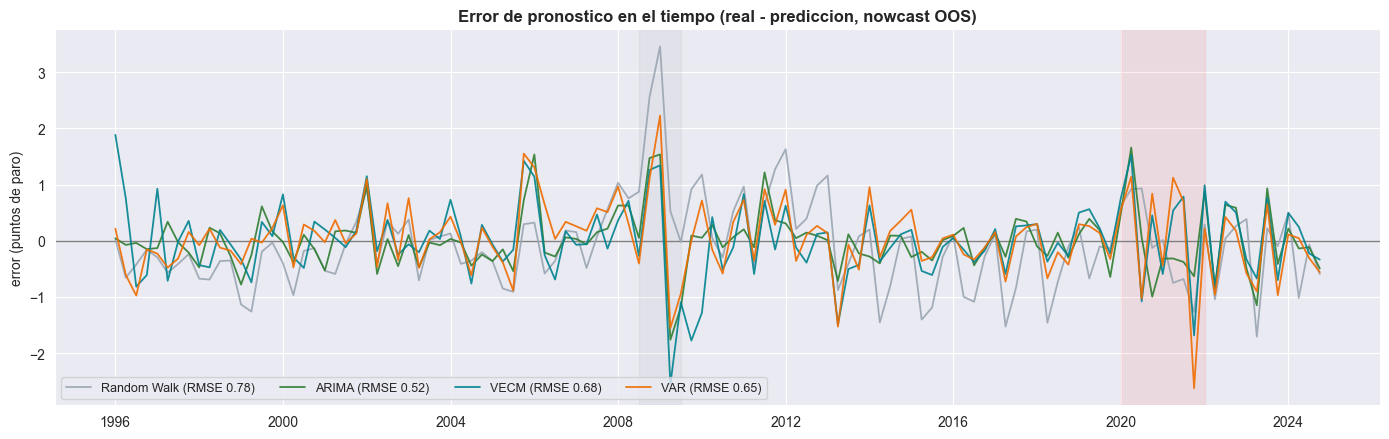

In [11]:
# RMSE por horizonte (comparacion directa) y error en el tiempo (vista de conjunto, sin sobreajuste)
plot_rmse_horizonte([("Random Walk", met_rw, C["rw"]), ("ARIMA", met_ar, C["arima"]),
                     ("VECM", met_vecm, C["vecm"]), ("VAR", met_var, C["var"])])

plot_errores([("Random Walk", preds_rw, C["rw"]), ("ARIMA", preds_ar, C["arima"]),
              ("VECM", preds_vecm, C["vecm"]), ("VAR", preds_var, C["var"])])

**Lectura de la comparativa.** El sistema macroeconómico, en su forma de VAR estacionario, supera al paseo aleatorio (1.694 frente a 1.883) gracias a la información del PIB y del crédito, pero no alcanza al benchmark ARIMA (1.531): la inercia propia del paro sigue siendo más informativa a corto plazo que la realimentación macro del sistema. En el stress-test COVID se mantiene el patrón general, con los modelos estructurados degradándose frente a un paseo aleatorio que arrastra el último valor. Para el ensamblaje se conservan ambas especificaciones, el VAR como representante del canal macro y el VECM por la diversidad de sus errores.

## 7. Evolucion esperada del paro

Proyeccion a cuatro trimestres con las dos especificaciones, ajustadas sobre la muestra completa, con sus bandas de confianza nativas (IC80 e IC95). Importa la diferencia de forma: el VAR estacionario tiende a la media de su dinamica reciente, mientras que el VECM arrastra la correccion hacia el equilibrio de cointegracion. Ambas se leen con la cautela del diagnostico inicial.

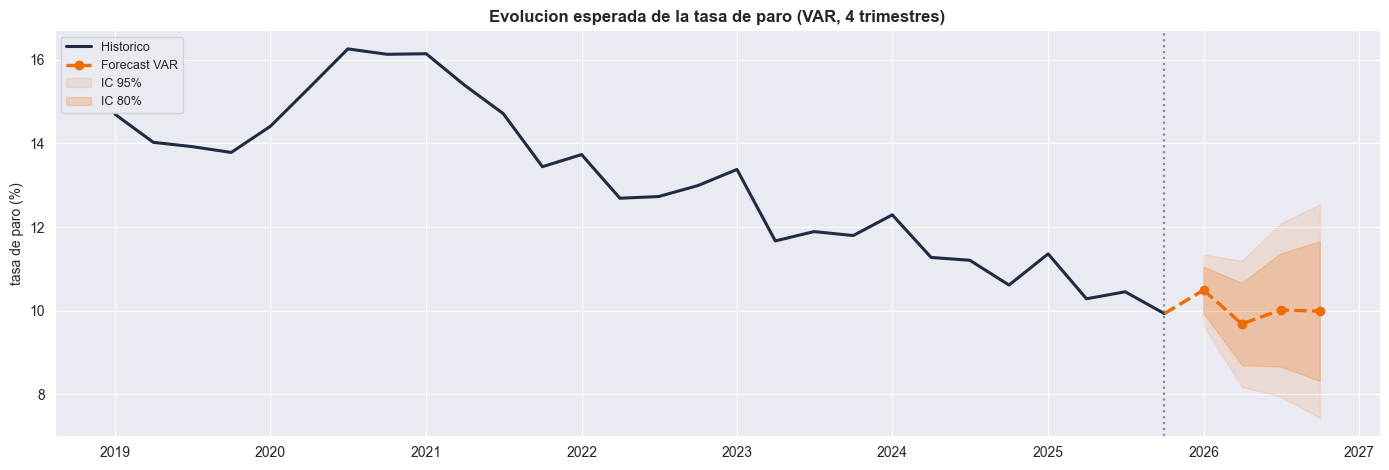

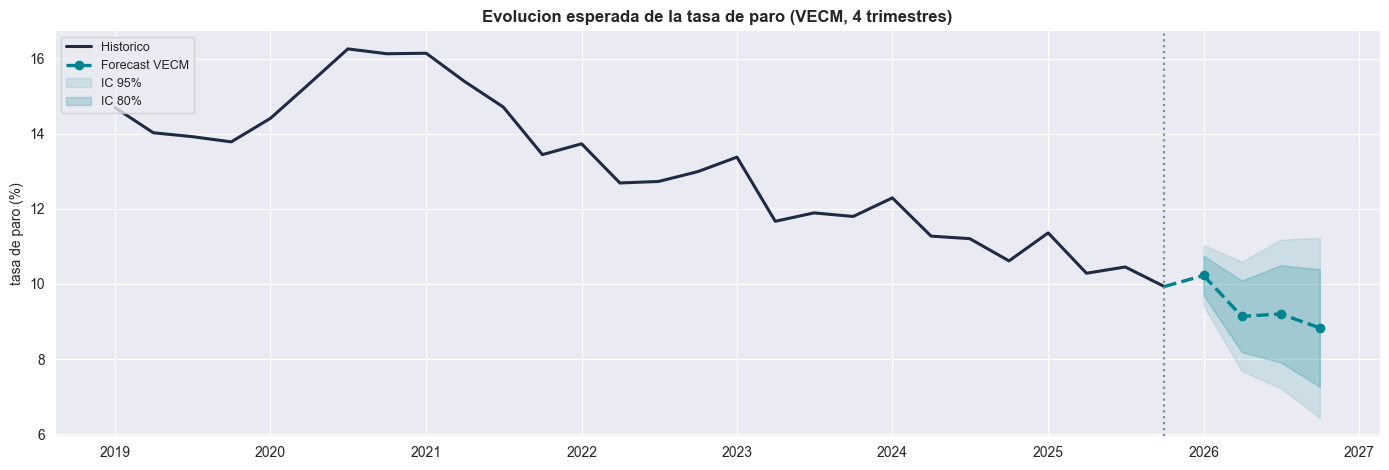

In [12]:
# VAR: proyeccion a 4 trimestres con bandas (forecast_interval nativo de statsmodels)
d_full = pd.DataFrame({"paro": y, "dpib": df["pib_pm"].diff(), "dcred": df["credito_privado"].diff()}).dropna()
rv = VAR(d_full).fit(maxlags=8, ic="bic")
m80, l80, u80 = rv.forecast_interval(d_full.values[-rv.k_ar:], steps=4, alpha=0.20)
_, l95, u95 = rv.forecast_interval(d_full.values[-rv.k_ar:], steps=4, alpha=0.05)
plot_futuro(m80[:, 0], l80[:, 0], u80[:, 0], l95[:, 0], u95[:, 0], "VAR", C["var"])

# VECM: proyeccion a 4 trimestres con bandas (predict con alpha)
rc = VECM(df.values, k_ar_diff=int(BEST_VECM["k_ar_diff"]), coint_rank=int(BEST_VECM["rango"]),
          deterministic=BEST_VECM["det"]).fit()
c80 = rc.predict(steps=4, alpha=0.20); c95 = rc.predict(steps=4, alpha=0.05)
plot_futuro(c80[0][:, 0], c80[1][:, 0], c80[2][:, 0], c95[1][:, 0], c95[2][:, 0], "VECM", C["vecm"])

In [13]:
pd.DataFrame({'trimestre': ["2026Q1", "2026Q2", "2026Q3", "2026Q4"],
              'forecast': m80[:, 0].round(2),
              'IC80_inf': l80[:, 0].round(2), 'IC80_sup': u80[:, 0].round(2),
              'IC95_inf': l95[:, 0].round(2), 'IC95_sup': u95[:, 0].round(2)}
            ).to_csv(RUTA_RESULTADOS / 'proyeccion_futura_var.csv', index=False)
print('guardado: proyeccion_futura_var.csv')

guardado: proyeccion_futura_var.csv


## 8. Cierre

Quedan guardados en `Resultados/` los pares `vecm` y `var` para el cuaderno de comparación y ensamblaje, con sus métricas por horizonte, el subperiodo COVID, el skill frente al suelo y al benchmark, la especificación elegida y el diagnóstico de error en entrenamiento frente a test.

**Checkpoint de honestidad.**

- **Hecho.** Sistema macro paro-PIB-crédito en dos especificaciones, VECM en niveles y VAR estacionario, con la configuración del VECM elegida por validación de orígenes expansivos (rango, rezago en diferencias y término determinista) y el orden del VAR por BIC en cada fold; ambas evaluadas en 116 folds del expanding window.
- **Hallazgo.** El VAR estacionario (RMSE global 1.694) bate al suelo pero no al ARIMA; el VECM (2.040) queda por detrás salvo en los dos horizontes más cortos. La diferencia confirma que, con la tasa de paro I(0), la cointegración de Johansen es en buena parte espuria y la especificación estacionaria es la correcta.
- **Diagnóstico train-test.** Gaps moderados (VAR 0.242, VECM 0.270), sin sobreajuste.
- **Stress-test.** Como el resto de modelos estructurados, el sistema macro se degrada en la COVID frente al paseo aleatorio.
- Para el ensamblaje se usan ambos, con el VAR como representante del canal macro.